### Multi-Class Classification


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

In [2]:
# Load the Data and Set up Train and Test Sets
iris = load_iris()
X = iris.data
y = iris.target

# Keep 20% for the test split size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Convert to float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [3]:
# Create the DataLoader

class IrisData(Dataset):
    def __init__(self, X_train, y_train) -> None:
        super().__init__()
        self.X = torch.from_numpy(X_train)
        self.y = torch.from_numpy(y_train)
        self.y = self.y.type(torch.LongTensor)
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
    def __len__(self):
        return self.len
    
iris_data = IrisData(X_train=X_train, y_train=y_train)
train_loader = DataLoader(dataset=iris_data, batch_size=32)

print(f"X Shape: {iris_data.X.shape}, y shape: {iris_data.y.shape}")

X Shape: torch.Size([120, 4]), y shape: torch.Size([120])


In [4]:
# Define the Netowrk Class

class MultiClassNetwork(nn.Module):
    def __init__(self, NUM_FEATURES, NUM_CLASSES, HIDDEN_FEATURES):
        super().__init__()
        self.linear1 = nn.Linear(NUM_FEATURES, HIDDEN_FEATURES)
        self.linear2 = nn.Linear(HIDDEN_FEATURES, NUM_CLASSES)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.sigmoid(x)
        x = self.linear2(x)
        x = self.log_softmax(x)
        return x

In [17]:
# Train the Classifier Network

NUM_FEATURES = iris_data.X.shape[1]
HIDDEN_FEATURES = 6
NUM_CLASSES = len(iris_data.y.unique())

LEARNING_RATE = 0.1
NUM_EPOCHS = 1000

model = MultiClassNetwork(NUM_FEATURES=NUM_FEATURES, NUM_CLASSES=NUM_CLASSES, HIDDEN_FEATURES=HIDDEN_FEATURES)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

losses = []

for epoch in range(NUM_EPOCHS):
    for x, y in train_loader:

        optimizer.zero_grad()

        y_hat_logits = model(x)

        loss = criterion(y_hat_logits, y)

        loss.backward()

        optimizer.step()
    
    losses.append(loss.item())

<Axes: >

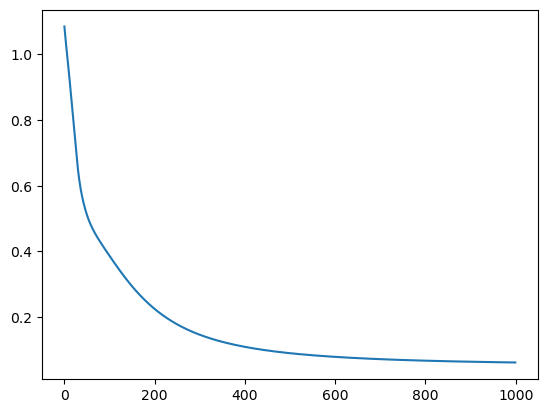

In [18]:
sns.lineplot(x=range(len(losses)), y=losses)

In [ ]:
# Test the Model
from collections import Counter

X_test_torch = torch.from_numpy(X_test)
with torch.no_grad():
    y_test_hat_softmax = model(X_test_torch)

    """ 
    torch.max returns two things: the max values along the specified dimension (here that means the highest score across classes)
    and the indices of those maximum values (i.e. which class index was chosen)
    """
    y_test_hat = torch.max(y_test_hat_softmax.data, 1)

# y_test_hat.indices extracts the predicted class labels
acc = accuracy_score(y_test, y_test_hat.indices)
print(f"Model Accuracy: {acc * 100:.2f} %")

# The Naive Classifier always predicts the most common class.
# most_common returns a list of (label, count) pairs so this line is getting the number of samples belonging to the most frequent class
most_common_count = Counter(y_test).most_common()[0][1]
print(f"Naive Classifier (baseline accuracy): {most_common_count / len(y_test) * 100} %")

Model Accuracy: 93.33 %
Naive Classifier: 46.666666666666664 %
